# Regresión Lineal Multivariable


## 1) Importar librerías
Importamos las herramientas que necesitamos:
- `numpy` y `pandas`: manejo de datos
- `matplotlib` y `seaborn`: visualización
- `sklearn`: modelo de regresión y métricas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Estilo de gráficos
sns.set_theme(style='whitegrid')
np.random.seed(42)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 2) Importar Dataset
### Variables entrada

- X1: Compacidad relativa
- X2: Área de superficie
- X3: Área de pared
- X4: Área de techo
- X5: Altura total
- X6: Orientación
- X7: Área de acristalamiento
- X8: Distribución del acristalamiento

### Variables salida

- Y1: Carga de calefacción
- Y2: Carga de refrigeración

In [ ]:
df = pd.read_csv("data_clean.csv")

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')

df.head()

Dataset cargado: 768 filas x 10 columnas


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,2.044054,-1.785875,-0.562800,-1.470077,1.0,-1.341641,-1.762934,-1.814575,15.55,21.33
1,2.044054,-1.785875,-0.562800,-1.470077,1.0,-0.447214,-1.762934,-1.814575,15.55,21.33
2,2.044054,-1.785875,-0.562800,-1.470077,1.0,0.447214,-1.762934,-1.814575,15.55,21.33
3,2.044054,-1.785875,-0.562800,-1.470077,1.0,1.341641,-1.762934,-1.814575,15.55,21.33
4,1.286851,-1.229239,-0.000733,-1.198678,1.0,-1.341641,-1.762934,-1.814575,20.84,28.28


## 3) Análisis exploratorio (EDA)
Antes de modelar, exploramos los datos:
- **`.describe()`**: estadísticas descriptivas (media, desviación, min, max)
- **`.info()`**: tipos de datos y valores nulos
- **Histogramas**: distribución de cada variable

In [ ]:
print('=== Estadísticas descriptivas ===')
display(df.describe().round(2))

print('\n=== Información del dataset ===')
df.info()

=== Estadísticas descriptivas ===


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.00,768.00,768.00,768.00,768.0,768.00,768.00,768.00,768.00,768.00
mean,0.00,-0.00,0.00,0.00,0.0,0.00,0.00,0.00,22.31,24.59
std,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,10.09,9.51
min,-1.36,-1.79,-1.69,-1.47,-1.0,-1.34,-1.76,-1.81,6.01,10.90
25%,-0.77,-0.74,-0.56,-0.79,-1.0,-0.67,-1.01,-0.69,12.99,15.62
50%,-0.13,0.02,-0.00,0.16,0.0,0.00,0.12,0.12,18.95,22.08
75%,0.53,0.79,0.56,0.97,1.0,0.67,1.24,0.77,31.67,33.13
max,2.04,1.55,2.25,0.97,1.0,1.34,1.24,1.41,43.10,48.03



=== Información del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    float64
 6   X7      768 non-null    float64
 7   X8      768 non-null    float64
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(10)
memory usage: 60.1 KB


##4) Visualizar distribuciones
Graficamos la distribución de cada variable para detectar sesgos o datos atípicos.

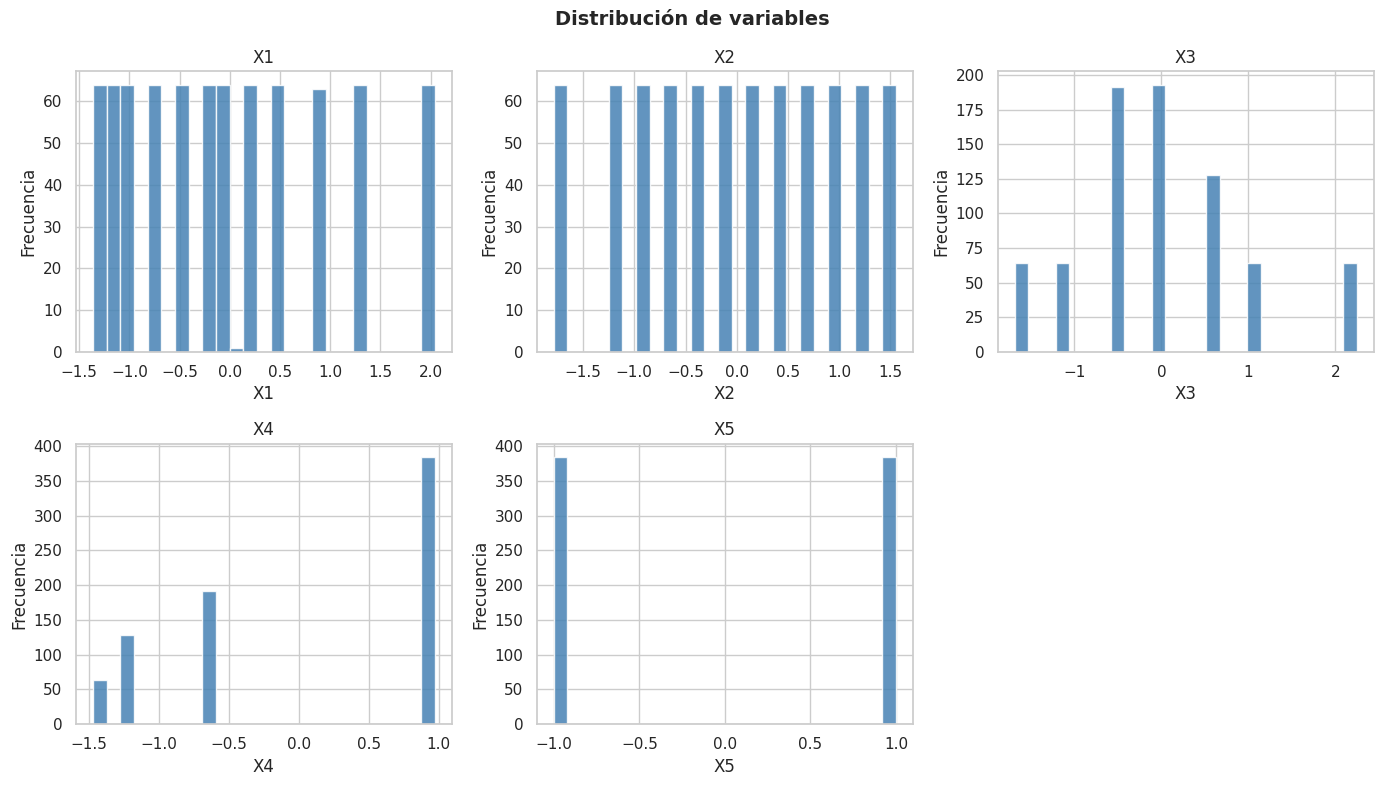

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
columnas = df.columns.tolist()

for ax, col in zip(axes.flatten(), columnas):
    ax.hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col.capitalize(), fontsize=12)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Frecuencia')

axes.flatten()[-1].set_visible(False)  # ocultar celda extra
plt.suptitle('Distribución de variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##5) Matriz de correlación
La correlación de Pearson (valores entre -1 y 1) mide la relación **lineal** entre pares de variables.
- Valores cercanos a **1** → correlación positiva fuerte
- Valores cercanos a **-1** → correlación negativa fuerte
- Valores cercanos a **0** → poca relación lineal

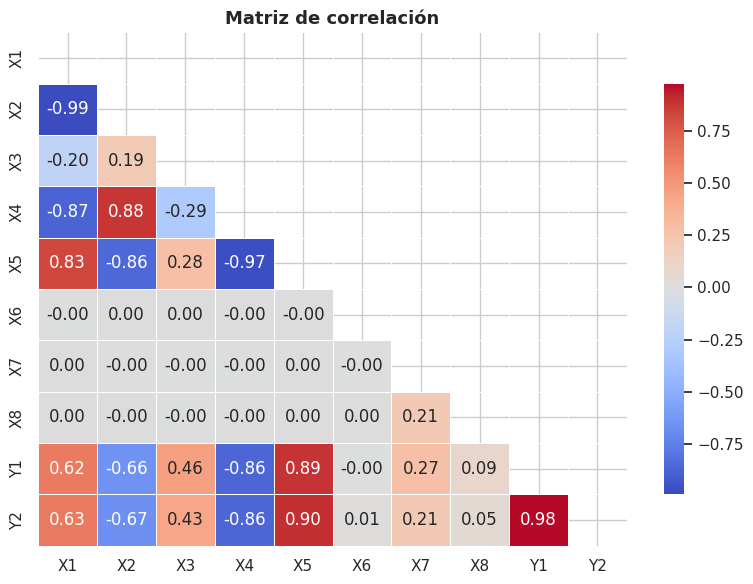

In [ ]:
plt.figure(figsize=(8, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # mostrar solo triángulo inferior

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})

plt.title('Matriz de correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6) Separar features y target
Dividimos el dataset en:
- **X**: matriz de features (variables independientes)
- **y**: vector target (variable a predecir)

Luego dividimos en **train (80%)** y **test (20%)** para evaluar el modelo con datos que no vio durante el entrenamiento.

In [ ]:
X = df[['X1','X2','X3','X4','X5','X6','X7','X8']]

# Objetivo
y = df['Y1']

#En caso de querer predecir Y2 se comenta la linea de arriba y se descomenta esta
# y = df['Y2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Entrenamiento : {X_train.shape[0]} muestras')
print(f'Prueba        : {X_test.shape[0]} muestras')

Entrenamiento : 614 muestras
Prueba        : 154 muestras


## 8) Entrenar el modelo
Entrenamos la regresión lineal con `LinearRegression` de scikit-learn.

Internamente, el modelo minimiza la **suma de errores cuadráticos (OLS)**:

$$\min_{\beta} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Una vez entrenado, extraemos los **coeficientes** β y el **intercepto** β₀.

In [ ]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=False)

print(f'Intercepto (β₀): {modelo.intercept_:,.2f}')
print('\nCoeficientes:')
display(coef_df)

Intercepto (β₀): 22.27

Coeficientes:


,Feature,Coeficiente
4,X5,7.229987
6,X7,2.681749
7,X8,0.328824
5,X6,-0.030043
2,X3,-0.239966
1,X2,-1.498411
3,X4,-6.075345
0,X1,-6.537908


## 9) — Visualizar coeficientes
Graficamos los coeficientes para interpretar el **peso de cada variable** en la predicción.

- Coeficiente **positivo** → más valor de la feature ↑ Carga de calefacción
- Coeficiente **negativo** → más valor de la feature ↓ Carga de calefacción

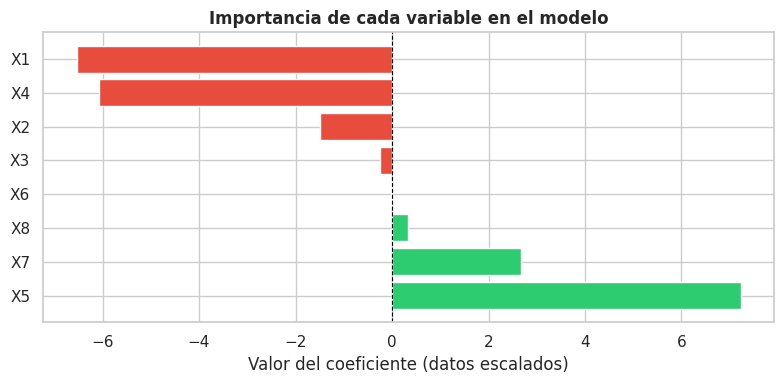

In [ ]:
colores = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coeficiente']]

plt.figure(figsize=(8, 4))
bars = plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colores, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Valor del coeficiente (datos escalados)')
plt.title('Importancia de cada variable en el modelo', fontweight='bold')
plt.tight_layout()
plt.show()

## 10) Evaluar el modelo
Usamos tres métricas estándar sobre el conjunto de **prueba**:

| Métrica | Descripción | Ideal |
|---|---|---|
| **MAE** | Error absoluto medio | Bajo |
| **RMSE** | Raíz del error cuadrático medio | Bajo |
| **R²** | Proporción de varianza explicada | Cercano a 1 |

In [ ]:
y_pred = modelo.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 35)
print(f'  MAE  : {mae:>12,.2f} ')
print(f'  RMSE : {rmse:>12,.2f} ')
print(f'  R²   : {r2:>12.4f}')
print('=' * 35)

  MAE  :         2.22 
  RMSE :         3.12 
  R²   :       0.9067


## 11) Gráfico Real vs. Predicho
Si el modelo fuera perfecto, todos los puntos caerían sobre la línea diagonal.
La dispersión alrededor de ella refleja el error del modelo.

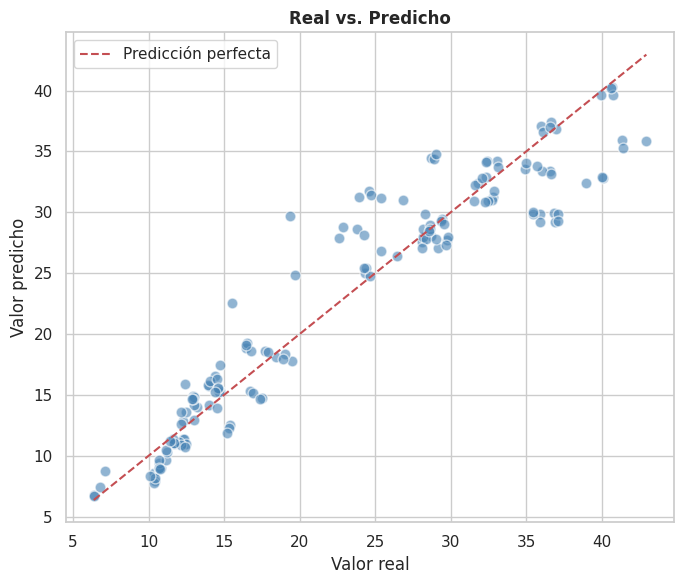

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=60)

lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')

plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Real vs. Predicho', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 12) Análisis de residuos
Los **residuos** son la diferencia entre el valor real y el predicho: $e_i = y_i - \hat{y}_i$

Un buen modelo debe tener residuos:
- **Distribuidos alrededor de 0** (sin sesgo sistemático)
- **Sin patrones** al graficarlos vs. los valores predichos (homocedasticidad)

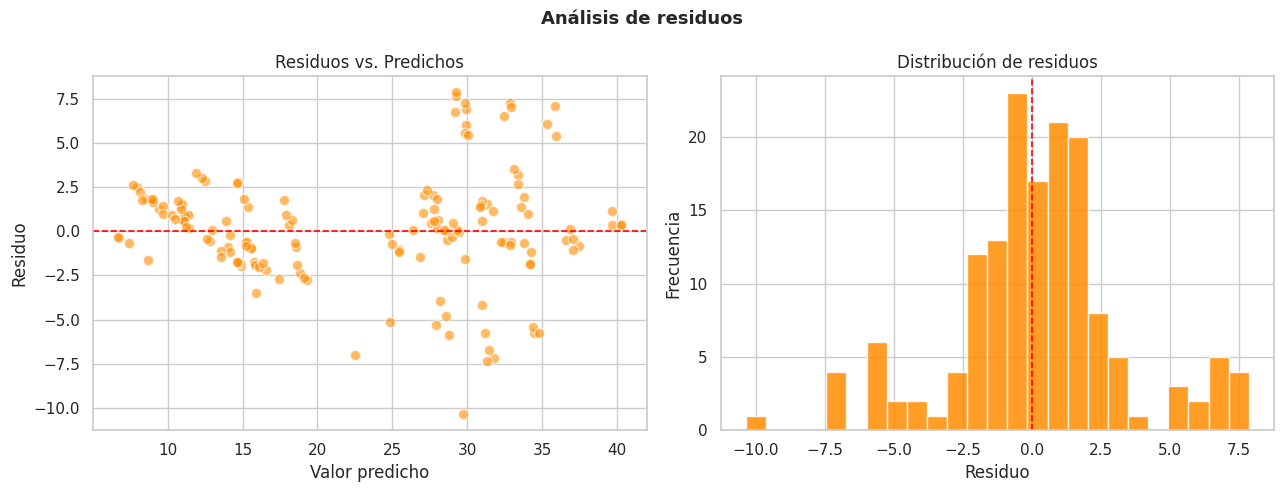

In [ ]:
residuos = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Residuos vs Predichos
ax1.scatter(y_pred, residuos, alpha=0.6, color='darkorange', edgecolors='white', s=55)
ax1.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax1.set_xlabel('Valor predicho')
ax1.set_ylabel('Residuo')
ax1.set_title('Residuos vs. Predichos')

# Distribución de residuos
ax2.hist(residuos, bins=25, color='darkorange', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.2)
ax2.set_xlabel('Residuo')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de residuos')

plt.suptitle('Análisis de residuos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13) Predicción con datos nuevos



In [ ]:
nuevos_datos = pd.DataFrame({
    'X1':[0.24569619805519116],
    'X2':[-0.3942840659863067],
    'X3':[0.561334393577643],
    'X4':[-0.6558803458962558],
    'X5':[1.0],
    'X6':[-1.3416407864998738],
    'X7':[-1.7629340689914434],
    'X8':[-1.8145751367274014]
})


prediccion = modelo.predict(nuevos_datos)

print("Predicción Y1:", prediccion[0])


Predicción Y1: 27.047026114096553


In [ ]:
nuevos_datos = pd.DataFrame({
    'X1':[2.044054],
    'X2':[-1.785875],
    'X3':[-0.562800],
    'X4':[-1.470077],
    'X5':[1.0],
    'X6':[-1.341641],
    'X7':[-1.762934],
    'X8':[-1.814575]
})

prediccion = modelo.predict(nuevos_datos)

print("Predicción Y1:", prediccion[0])

Predicción Y1: 22.59098192381878


In [ ]:
pred_todo = modelo.predict(X)

resultado = pd.DataFrame({
    'Real': y,
    'Predicho': pred_todo,
    'Error': abs(y - pred_todo)
})

resultado.sort_values('Error', ascending=False).head(10)

,Real,Predicho,Error
10,19.34,29.703446,10.363446
15,15.98,25.661877,9.681877
14,16.95,25.688748,8.738748
12,17.05,25.742491,8.692491
13,17.41,25.715619,8.305619
65,37.12,29.247972,7.872028
113,37.26,29.460123,7.799877
305,40.03,32.271469,7.758531
353,40.19,32.483621,7.706379
66,36.90,29.221100,7.678900


#Red Neuronal MultiCapa

##1) Importar Librerias

Se evita importar librerias usadas anteriormente

In [ ]:
from sklearn.neural_network import MLPRegressor

sns.set_theme(style='whitegrid')

print("✅ Librerías cargadas")

✅ Librerías cargadas


##2) Cargar Data Set

En el ejercicio anterior ya se habia realizado la carga por tanto, se verifica que se encuentre disponible

In [ ]:
print(df.shape)
df.head()

(768, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,2.044054,-1.785875,-0.562800,-1.470077,1.0,-1.341641,-1.762934,-1.814575,15.55,21.33
1,2.044054,-1.785875,-0.562800,-1.470077,1.0,-0.447214,-1.762934,-1.814575,15.55,21.33
2,2.044054,-1.785875,-0.562800,-1.470077,1.0,0.447214,-1.762934,-1.814575,15.55,21.33
3,2.044054,-1.785875,-0.562800,-1.470077,1.0,1.341641,-1.762934,-1.814575,15.55,21.33
4,1.286851,-1.229239,-0.000733,-1.198678,1.0,-1.341641,-1.762934,-1.814575,20.84,28.28


##3) Separar Variables

In [ ]:
X = df.drop(columns=['Y1', 'Y2'])
y = df['Y1']

# y = df['Y2']

##4) División Train/Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (614, 8)
Test : (154, 8)


##5) Crear la Red Neuronal

In [ ]:
modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=3000,
    random_state=42
)

modelo_mlp.fit(X_train, y_train)

print("Modelo entrenado")

Modelo entrenado


##6) Evaluación

In [ ]:
y_pred = modelo_mlp.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*35)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print("="*35)

MAE  : 0.4505
RMSE : 0.6039
R²   : 0.9965


##7) Real vs Predicho

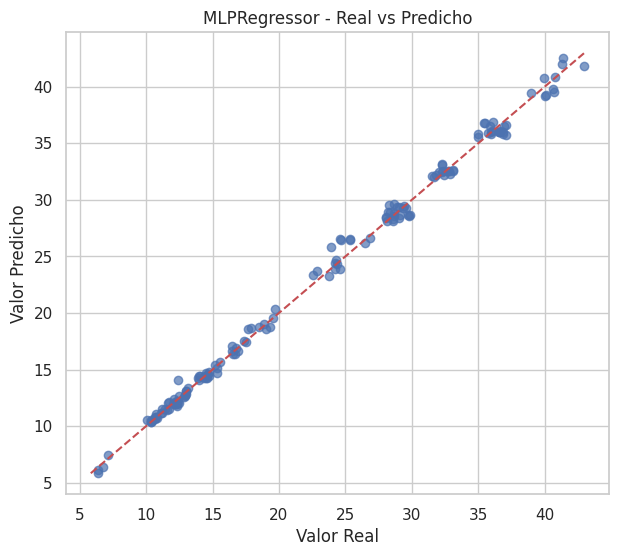

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

lim = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(lim, lim, 'r--')

plt.xlabel("Valor Real")
plt.ylabel("Valor Predicho")
plt.title("MLPRegressor - Real vs Predicho")

plt.show()

##8) Pérdida durante el entrenamiento

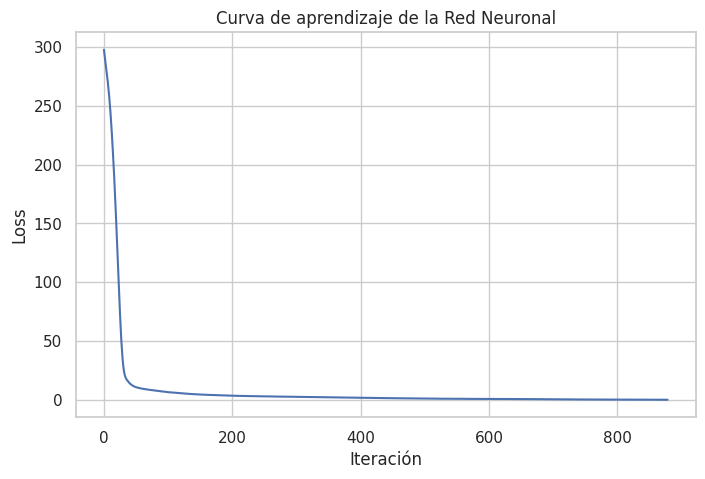

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(modelo_mlp.loss_curve_)

plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.title("Curva de aprendizaje de la Red Neuronal")

plt.show()

## 9) Predicción con datos nuevos

In [ ]:
nuevo = pd.DataFrame({
    'X1':[2.044054],
    'X2':[-1.785875],
    'X3':[-0.562800],
    'X4':[-1.470077],
    'X5':[1.0],
    'X6':[-1.341641],
    'X7':[-1.762934],
    'X8':[-1.814575]
})

pred = modelo_mlp.predict(nuevo)

print("Predicción Y1:", pred[0])

Predicción Y1: 16.309247362545854


In [ ]:
resultados = pd.DataFrame({
    "Real": y_test,
    "Predicho": y_pred,
    "Error": abs(y_test - y_pred)
})

resultados.sort_values("Error", ascending=False).head(10)

,Real,Predicho,Error
23,23.93,25.856589,1.926589
494,24.60,26.515115,1.915115
396,24.70,26.484537,1.784537
748,12.43,14.087172,1.657172
65,37.12,35.762078,1.357922
210,35.45,36.757846,1.307846
259,35.48,36.766446,1.286446
199,29.79,28.551536,1.238464
244,29.83,28.619722,1.210278
490,28.31,29.507311,1.197311


##